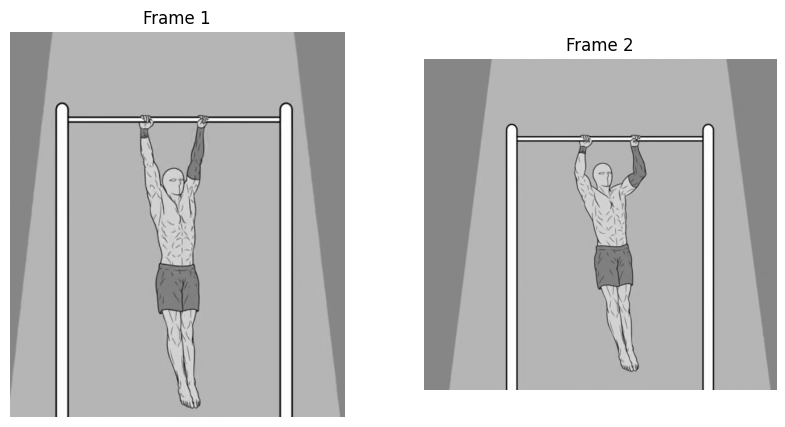

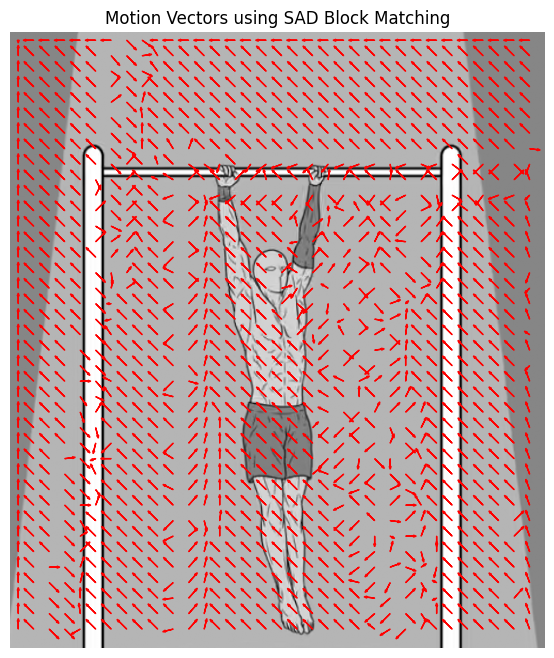

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load grayscale images
frame1 = cv2.imread('/content/im1.png', cv2.IMREAD_GRAYSCALE)
frame2 = cv2.imread('/content/im2.png', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(frame1, cmap='gray')
plt.title("Frame 1")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(frame2, cmap='gray')
plt.title("Frame 2")
plt.axis('off')

plt.show()

if frame1 is None or frame2 is None:
    raise ValueError("Image path wrong")

# Force identical size
h = min(frame1.shape[0], frame2.shape[0])
w = min(frame1.shape[1], frame2.shape[1])

frame1 = frame1[:h, :w].astype(np.float32)
frame2 = frame2[:h, :w].astype(np.float32)

block_size = 16
search_range = 8

motion_vectors = []

for y in range(0, h - block_size + 1, block_size):
    for x in range(0, w - block_size + 1, block_size):

        block = frame1[y:y+block_size, x:x+block_size]

        min_sad = float('inf')
        best_dx = 0
        best_dy = 0

        for dy in range(-search_range, search_range + 1):
            for dx in range(-search_range, search_range + 1):

                y2 = y + dy
                x2 = x + dx

                # Strict boundary condition
                if (y2 < 0 or x2 < 0 or
                    y2 + block_size > h or
                    x2 + block_size > w):
                    continue

                candidate = frame2[y2:y2+block_size, x2:x2+block_size]

                # Safety check
                if candidate.shape != block.shape:
                    continue

                sad = np.sum(np.abs(block - candidate))

                if sad < min_sad:
                    min_sad = sad
                    best_dx = dx
                    best_dy = dy

        motion_vectors.append((x, y, best_dx, best_dy))

# Visualize motion vectors
plt.figure(figsize=(8,8))
plt.imshow(frame1, cmap='gray')

for (x, y, dx, dy) in motion_vectors:
    plt.arrow(x + block_size//2,
              y + block_size//2,
              dx, dy,
              color='red',
              head_width=2)

plt.title("Motion Vectors using SAD Block Matching")
plt.axis('off')
plt.show()
